In [47]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [ ]:
# read 48hrs of telekom data
curfew_path = '../output/data/48hr_averages/curfew_avg48hrs.pkl' 
open_path = '../output/data/48hr_averages/open_avg48hrs.pkl'

curfew = pd.read_pickle(curfew_path)
opening = pd.read_pickle(open_path)

# create socio-econ variables

In [49]:
def add_socioecon_ratios(df):
    """Add sex/arpu/age composition ratios (each group of ratios sums to 1 within itself)."""
    df = df.copy()

    sex_total = df['sex_male'] + df['sex_female'] + df['sex_na']
    df['sex_fem_ratio'] = df['sex_female'] / sex_total
    df['sex_male_ratio'] = df['sex_male'] / sex_total

    arpu_total = df['arpu_low'] + df['arpu_mid'] + df['arpu_high'] + df['arpu_na']
    df['arpu_low_ratio'] = df['arpu_low'] / arpu_total
    df['arpu_mid_ratio'] = df['arpu_mid'] / arpu_total
    df['arpu_high_ratio'] = df['arpu_high'] / arpu_total

    age_total = df['age_young'] + df['age_mid'] + df['age_old'] + df['age_na']
    df['age_young_ratio'] = df['age_young'] / age_total
    df['age_old_ratio'] = df['age_old'] / age_total
    df['age_mid_ratio'] = df['age_mid'] / age_total

    return df

opening = add_socioecon_ratios(opening)
curfew = add_socioecon_ratios(curfew)

In [50]:
# Keep only the generated ratio columns along with 'hour_reordered' and 'raster_id'
ratio_cols = ['raster_id', 'hour_reordered', 'sex_fem_ratio', 'sex_male_ratio',
              'arpu_low_ratio', 'arpu_mid_ratio', 'arpu_high_ratio',
              'age_young_ratio', 'age_old_ratio', 'age_mid_ratio']

opening_filtered = opening[ratio_cols]
curfew_filtered = curfew[ratio_cols]

In [51]:
# create a new df with these socio econ variables, keeping only raster_id/hour_reordered
socioecon = pd.merge(opening_filtered, curfew_filtered, on=['raster_id', 'hour_reordered'], how='inner', suffixes=('_open', '_curfew'))

In [52]:
# Subtraction to calculate the changes between opening and curfew periods.
# Convention throughout: curfew - open, so a negative value means a decrease during curfew.
socioecon['fem_ratio_change'] = socioecon['sex_fem_ratio_curfew'] - socioecon['sex_fem_ratio_open']
socioecon['arpu_low_change'] = socioecon['arpu_low_ratio_curfew'] - socioecon['arpu_low_ratio_open']
socioecon['arpu_high_change'] = socioecon['arpu_high_ratio_curfew'] - socioecon['arpu_high_ratio_open']
socioecon['age_young_change'] = socioecon['age_young_ratio_curfew'] - socioecon['age_young_ratio_open']
socioecon['age_old_change'] = socioecon['age_old_ratio_curfew'] - socioecon['age_old_ratio_open']
socioecon['age_mid_change'] = socioecon['age_mid_ratio_curfew'] - socioecon['age_mid_ratio_open']

In [53]:
# get an average change/ratio per workday
socioecon_workhrs = socioecon[socioecon['hour_reordered'].isin(range(8, 18))]
socioecon_workday2 = socioecon_workhrs.drop(columns=['hour_reordered'])

#Group by 'raster_id' and calculate the mean for each group
socioecon_workday = socioecon_workday2.groupby('raster_id').mean().reset_index()

# Calculate socio-economic entropy

In [54]:
# Function to calculate Shannon entropy
#  for each stop_id location, which measures the uncertainty of social mix within that location
def shannon_entropy(probs):
    return entropy(probs, base=2)

def compute_entropy_from_ratios(df, entropy_col_name):
    """Given a dataframe whose columns are a set of ratio values representing a distribution
    across categories, normalize each row to sum to 1 and compute Shannon entropy. Rows that
    sum to 0 are dropped."""
    probs = df.div(df.sum(axis=1), axis=0).fillna(0)
    probs = probs[(probs != 0).any(axis=1)]
    entropies = probs.apply(shannon_entropy, axis=1)
    return entropies.reset_index(name=entropy_col_name)

# Entropy 1: workday average

In [55]:
# full entropy for opening
change_cols = ['fem_ratio_change', 'arpu_low_change', 'arpu_high_change',
               'age_young_change', 'age_old_change', 'age_mid_change']

open_workday = socioecon_workday.drop(columns=[
    'sex_fem_ratio_curfew', 'sex_male_ratio_curfew',
    'arpu_low_ratio_curfew', 'arpu_mid_ratio_curfew', 'arpu_high_ratio_curfew',
    'age_young_ratio_curfew', 'age_old_ratio_curfew', 'age_mid_ratio_curfew',
] + change_cols)

open_workday2 = open_workday.set_index('raster_id')

curfew_workday = socioecon_workday.drop(columns=[
    'sex_fem_ratio_open', 'sex_male_ratio_open',
    'arpu_low_ratio_open', 'arpu_mid_ratio_open', 'arpu_high_ratio_open',
    'age_young_ratio_open', 'age_old_ratio_open', 'age_mid_ratio_open',
] + change_cols)

curfew_workday2 = curfew_workday.set_index('raster_id')

In [56]:
socioecon_entr_open = compute_entropy_from_ratios(open_workday2, 'socioecon_entr_open')
socioecon_entr_curfew = compute_entropy_from_ratios(curfew_workday2, 'socioecon_entr_curfew')

In [57]:
# Income entropy
open_workday3 = open_workday2.drop(columns=['sex_fem_ratio_open', 'sex_male_ratio_open', 'age_young_ratio_open',
       'age_old_ratio_open', 'age_mid_ratio_open'])

curfew_workday3 = curfew_workday2.drop(columns=['sex_fem_ratio_curfew', 'sex_male_ratio_curfew', 'age_young_ratio_curfew',
       'age_old_ratio_curfew', 'age_mid_ratio_curfew'])

In [58]:
# Calculate entropy 
income_entr_open = compute_entropy_from_ratios(open_workday3, 'income_entr_open')
income_entr_curfew = compute_entropy_from_ratios(curfew_workday3, 'income_entr_curfew')

In [59]:
# Each entropy df from compute_entropy_from_ratios
entropy_dfs = [socioecon_entr_open, socioecon_entr_curfew, income_entr_open, income_entr_curfew]

# Merge all entropy DataFrames with socioecon_workday based on 'raster_id'
for entr_df in entropy_dfs:
    socioecon_workday = socioecon_workday.merge(entr_df, on='raster_id', how='left')

In [60]:
socioecon_workday['income_entr_change'] = socioecon_workday['income_entr_curfew'] - socioecon_workday['income_entr_open']
socioecon_workday['socioecon_entr_change'] = socioecon_workday['socioecon_entr_curfew'] - socioecon_workday['socioecon_entr_open']

# Entropy per hour

In [61]:
open_hourly = socioecon.drop(columns=[
    'sex_fem_ratio_curfew', 'sex_male_ratio_curfew',
    'arpu_low_ratio_curfew', 'arpu_mid_ratio_curfew', 'arpu_high_ratio_curfew',
    'age_young_ratio_curfew', 'age_old_ratio_curfew', 'age_mid_ratio_curfew',
] + change_cols)
open_hourly2 = open_hourly.set_index(['raster_id', 'hour_reordered'])

curfew_hourly = socioecon.drop(columns=[
    'sex_fem_ratio_open', 'sex_male_ratio_open',
    'arpu_low_ratio_open', 'arpu_mid_ratio_open', 'arpu_high_ratio_open',
    'age_young_ratio_open', 'age_old_ratio_open', 'age_mid_ratio_open',
] + change_cols)
curfew_hourly2 = curfew_hourly.set_index(['raster_id', 'hour_reordered'])

socioecon_entr_open_h = compute_entropy_from_ratios(open_hourly2, 'socioecon_entr_open')
socioecon_entr_curfew_h = compute_entropy_from_ratios(curfew_hourly2, 'socioecon_entr_curfew')

In [62]:
# Income entropy, per hour
open_hourly3 = open_hourly2.drop(columns=['sex_fem_ratio_open', 'sex_male_ratio_open', 'age_young_ratio_open',
       'age_old_ratio_open', 'age_mid_ratio_open'])

curfew_hourly3 = curfew_hourly2.drop(columns=['sex_fem_ratio_curfew', 'sex_male_ratio_curfew', 'age_young_ratio_curfew',
       'age_old_ratio_curfew', 'age_mid_ratio_curfew'])

income_entr_open_h = compute_entropy_from_ratios(open_hourly3, 'income_entr_open')
income_entr_curfew_h = compute_entropy_from_ratios(curfew_hourly3, 'income_entr_curfew')

In [63]:
# Merge the per-hour entropy measures onto socioecon (all 48 hours)
entropy_dfs_hourly = [socioecon_entr_open_h, socioecon_entr_curfew_h, income_entr_open_h, income_entr_curfew_h]

for entr_df in entropy_dfs_hourly:
    socioecon = socioecon.merge(entr_df, on=['raster_id', 'hour_reordered'], how='left')

socioecon['income_entr_change'] = socioecon['income_entr_curfew'] - socioecon['income_entr_open']
socioecon['socioecon_entr_change'] = socioecon['socioecon_entr_curfew'] - socioecon['socioecon_entr_open']

# Calculate workplace dependence and change in population between the periods

# CHECK HERE for var names

In [79]:
# calculate change in working population
# negative values mean that there is a decrease in nr of workers during curfew

# Merge curfew and opening on 'raster_id' and 'hour_reordered'
work_df = pd.merge(curfew, opening, on=['raster_id', 'hour_reordered'], how='inner', suffixes=('_curfew', '_opening'))

# Restrict to raster_ids that are genuine workplaces during curfew.
#work_df = full_df[full_df['loc_work_gaussian_curfew'] > 0].copy()

# Calculate the difference for the specified columns
work_df.loc[:, 'work_abs_diff'] = work_df['loc_work_gaussian_curfew'] - work_df['loc_work_gaussian_opening']
#work_df.loc[:, 'work_norm_diff'] = work_df['log_work_gauss_norm_curfew'] - work_df['log_work_gauss_norm_opening']
work_df.loc[:, 'traffic_abs_diff'] = work_df['traffic_gaussian_curfew'] - work_df['traffic_gaussian_opening']
#work_df.loc[:, 'traffic_norm_diff'] = work_df['log_traffic_gauss_norm_curfew'] - work_df['log_traffic_gauss_norm_opening']
work_df.loc[:, 'low_income_diff'] = work_df['arpu_low_curfew'] - work_df['arpu_low_opening']
work_df.loc[:, 'mid_income_diff'] = work_df['arpu_mid_curfew'] - work_df['arpu_mid_opening']
work_df.loc[:, 'high_income_diff'] = work_df['arpu_high_curfew'] - work_df['arpu_high_opening']
work_df.loc[:, 'fem_diff'] = work_df['sex_female_curfew'] - work_df['sex_female_opening']
work_df.loc[:, 'male_diff'] = work_df['sex_male_curfew'] - work_df['sex_male_opening']
work_df.loc[:, 'young_diff'] = work_df['age_young_curfew'] - work_df['age_young_opening']
work_df.loc[:, 'midage_diff'] = work_df['age_mid_curfew'] - work_df['age_mid_opening']
work_df.loc[:, 'old_diff'] = work_df['age_old_curfew'] - work_df['age_old_opening']

# Create a new dataframe with the results
work_diff = work_df[['raster_id', 'hour_reordered',
                         'work_abs_diff',
                         'traffic_abs_diff',
                        'loc_work_gaussian_opening','traffic_gaussian_opening',
                        'log_work_no0_opening', 'log_work_gauss_norm_opening', 'low_income_diff', 'mid_income_diff', 'high_income_diff',
                        'arpu_low_opening',  'arpu_high_opening', 'fem_diff', 'male_diff', 'young_diff', 'midage_diff', 'old_diff']] 

In [80]:
# get an average change per workday
work_diff_workday = work_diff[work_diff['hour_reordered'].isin(range(8, 18))]
work_diff_workday2 = work_diff_workday.drop(columns=['hour_reordered'])

#Group by 'raster_id' and calculate the mean for each group
work_diff2 = work_diff_workday2.groupby('raster_id').mean().reset_index()

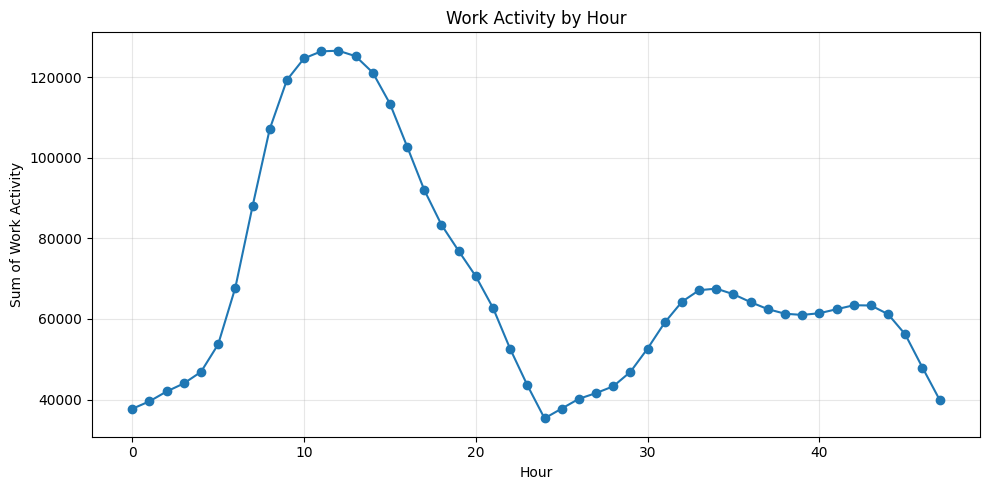

In [81]:
work_diff.columns
work_diff.groupby('hour_reordered')['loc_work_gaussian_opening'].sum().plot(
    kind='line', marker='o', figsize=(10, 5)
)
plt.xlabel('Hour')
plt.ylabel('Sum of Work Activity')
plt.title('Work Activity by Hour')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [82]:
# get the change at a certain - highest - workhour - 12
work_diff3 = work_diff[work_diff['hour_reordered'] == 12]

In [83]:
# merge the new population density information created in this dataset and save it.
os.makedirs("../output/data", exist_ok=True) 

# 1. Workday average: socio-econ ratios/changes/entropy averaged over hours 8-17,
#    merged with the workday-averaged workplace-dependence changes
population_density_workday = socioecon_workday.merge(work_diff2, on='raster_id', how='left')
population_density_workday.to_pickle("../output/data/population_density_workday_avg.pkl")

# 2. Noon snapshot: uses the per-hour entropy at noon, merged with the hour-12 workplace-dependence changes
socioecon_noon = socioecon[socioecon['hour_reordered'] == 12].drop(columns=['hour_reordered'])
population_density_noon = socioecon_noon.merge(
    work_diff3.drop(columns=['hour_reordered']), on='raster_id', how='left'
)
population_density_noon.to_pickle("../output/data/population_density_hour12.pkl")

# 3. All hours: full per-hour socio-econ + entropy
population_density_all_hours = socioecon.merge(work_diff, on=['raster_id', 'hour_reordered'], how='left')
population_density_all_hours.to_pickle("../output/data/population_density_all_hours.pkl")